# **0. Описание ноутбука**

**Целью ноутбука** является выбрать среди базовых моделей наилучшую модель для дальнейшего его развития и использования

**Содержание:**
1. Подготовка датасета, библиотек, функций и переменных;
2. Обучение моделей;
3. Общей итог работы.

**Обучение и сравнение моделей:**
В ноутбуке присуствуют такие модели как:
```
Логистическая регрессия, SVM, Дерево значений, Случайный лес, Стекинг, CatBoost
```
Для каждой модели будут представлены 3 варианта данных для сравнения и подтверждения какая лучше на практике:

1.   Без BMI, но с Ростом и Весом
2.   С BMI, но без Роста и Веса
3.   Без BMI и без Роста и Веса

Для сравнение обратим внимание на такие метрики:
- F1-Score
- Log Loss
- Roc-auc
- Время обучения
- Precision
- Recall
- Accuracy


Важными метриками для нас являются:
- **F1-Score** из-за средних показателей Precision и Recall, а также из-за в отличие от Accuracy более надежен при дисбалансе классов;
- **Время обучения**, т.к. показывает скорость обучения;
- **Log Loss** для показа насколько можно довериться вроятностям модели;
- **ROC-AUC** для показа способности модели разделять классы.


# **1.1. Подготовка данных и инструментов**

*Описание импортов библиотек и готовых данных и инструментов*

## Загрузка и обработка данных

In [1]:
from pathlib import Path
import sys, os

REPO_DIR = 'Multiclass_prediction_of_obesity_risk'
REPO_URL = 'https://github.com/AlexTilta/Multiclass_prediction_of_obesity_risk.git'

if not os.path.isdir(REPO_DIR):
    print("Репозиторий не найден. Клонирование и установка зависимостей...")
    !git clone {REPO_URL}

    !pip -q install -r {REPO_DIR}/requirements.txt
else:
    print(f"Репозиторий '{REPO_DIR}' уже склонирован.")

%cd {REPO_DIR}

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


from src.utils import load_csv

df_original = load_csv('prepared_data.csv', 'data')
df_original.head()

Репозиторий не найден. Клонирование и установка зависимостей...


Cloning into 'Multiclass_prediction_of_obesity_risk'...
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      + C:\Program Files\Python313\python.exe C:\Users\РџРѕР»СЊР·РѕРІР°С‚РµР»СЊ\AppData\Local\Temp\pip-install-kynqr2io\numpy_f1e8a7949cb3481793e2feb187101ae1\vendored-meson\meson\meson.py setup C:\Users\РџРѕР»СЊР·РѕРІР°С‚РµР»СЊ\AppData\Local\Temp\pip-install-kynqr2io\numpy_f1e8a7949cb3481793e2feb187101ae1 C:\Users\РџРѕР»СЊР·РѕРІР°С‚РµР»СЊ\AppData\Local\Temp\pip-install-kynqr2io\numpy_f1e8a7949cb3481793e2feb187101ae1\.mesonpy-4qbx_c81 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\РџРѕР»СЊР·РѕРІР°С‚РµР»СЊ\AppData\Local\Temp\pip-install-kynqr2io\numpy_f1e8a7949cb3481793e2feb187101ae1\.mesonpy-4qbx_c81\meson-python-native-file.ini
      The Meson build system
      Version: 1.4.99
      Source dir: C:\Users\РџРѕР»СЊР·РѕРІР°С‚РµР»СЊ\AppData\Local\Temp\pip

c:\Users\Пользователь\OneDrive\Desktop\Новая папка (3)\Multiclass_prediction_of_obesity_risk\Multiclass_prediction_of_obesity_risk


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0,1.62,64.0,yes,no,Sometimes,3,Sometimes,no,1-2,no,0,3-5,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,Always,3,Sometimes,yes,>2,yes,4-5,0-2,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,Sometimes,3,Sometimes,no,1-2,no,2-4,3-5,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,Always,3,Sometimes,no,1-2,no,2-4,0-2,Frequently,Walking,Overweight,26.851852
4,Male,22.0,1.78,89.8,no,no,Sometimes,1-2,Sometimes,no,1-2,no,0,0-2,Sometimes,Public_Transportation,Overweight,28.342381


 ## Установка библиотек

In [72]:
!pip show catboost || pip install catboost
!pip show phik || pip install phik
!pip show optuna || pip install optuna

Name: catboost
Version: 1.2.8
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
Name: phik
Version: 0.12.5
Summary: Phi_K correlation analyzer library
Home-page: 
Author: 
Author-email: "KPMG N.V. The Netherlands" <kave@kpmg.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, matplotlib, numpy, pandas, scipy
Required-by: 
Name: optuna
Version: 4.6.0
Summary: A hyperparameter optimization framework
Home-page: https://optuna.org/
Author: Takuya Akiba
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: alembic, colorlog, numpy, packaging, PyYAML, sqlalchemy, tqdm
Required-by: 


## Библиотеки

In [2]:
# Общие библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import optuna
import warnings
from matplotlib import pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from optuna.trial import Trial

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score # <-- ДОБАВЛЕНО
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, PolynomialFeatures
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, log_loss, roc_auc_score
)
# Библиотеки для отчетов
import json
import time
from IPython.display import display

# Утилиты
import joblib
import warnings
warnings.filterwarnings('ignore')
from phik import phik_matrix


# Библиотеки моделей или для конкретных моделей
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier
)
from catboost import CatBoostClassifier, Pool, cv

C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **1.2. Настройка датасета**

*Описание констант для датасета(для быстрой настройки) и преобразования категориальных данных в числовые*

## Константы (для отчетов и редактирования наименований признаков)

In [3]:
# Целева переменная
TARGET_COLUMN = 'NObeyesdad'

# Константы для разных видов данных
ANTHROPOMETRICS = ['Height', 'Weight', 'BMI']

COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY = [TARGET_COLUMN, 'BMI']
COLUMNS_TO_DROP_BMI_ONLY = [TARGET_COLUMN, 'Height', 'Weight']
COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED = [TARGET_COLUMN] + ANTHROPOMETRICS

## Преобразование данных для большинство моделей

In [4]:
# Копирование данных (оригинал пригодится для CatBoost)
df_transformed = df_original.copy()

# Подготовка для преобразования строковых признаков
caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_transformed['CAEC'] = df_transformed['CAEC'].replace(caec_calc_map)
df_transformed['CALC'] = df_transformed['CALC'].replace(caec_calc_map)

fcvc_map = {'no': 0, 'Sometimes': 1, 'Always': 2}
df_transformed['FCVC'] = df_transformed['FCVC'].replace(fcvc_map)

ncp_map = {'1-2': 1.5, '3': 3.0, '>3': 3.5}
df_transformed['NCP'] = df_transformed['NCP'].replace(ncp_map)

ch2o_map = {'<1': 0.5, 'Sometimes': 1.0, '1-2': 1.5, '>2': 3.0}
df_transformed['CH2O'] = df_transformed['CH2O'].replace(ch2o_map)

faf_tue_map = {'0': 0, 'no': 0, '0-2': 1, '1-2': 1, '2-4': 3,
               '3-5': 4, '4-5': 4, '>5': 5}
df_transformed['FAF'] = df_transformed['FAF'].replace(faf_tue_map)
df_transformed['TUE'] = df_transformed['TUE'].replace(faf_tue_map)

yes_no_map = {'yes': 1.0, 'no': 0.0}
df_transformed['family_history_with_overweight'] = df_transformed['family_history_with_overweight'].replace(yes_no_map)
df_transformed['FAVC'] = df_transformed['FAVC'].replace(yes_no_map)
df_transformed['SMOKE'] = df_transformed['SMOKE'].replace(yes_no_map)
df_transformed['SCC'] = df_transformed['SCC'].replace(yes_no_map)

gender_map = {'Male': 1.0, 'Female': 0.0}
df_transformed['Gender'] = df_transformed['Gender'].replace(gender_map)

# Преобразование
mtrans_le = LabelEncoder()
df_transformed['MTRANS'] = mtrans_le.fit_transform(df_transformed['MTRANS']).astype(float)

df = df_transformed

INT_COLUMNS = ['FCVC', 'CAEC', 'FAF', 'TUE', 'CALC']
INT_COLUMNS_ADJUSTED = [col for col in INT_COLUMNS if col in df.columns]

for col in INT_COLUMNS_ADJUSTED:
    df[col] = df[col].astype('Int64')

EXCLUDE_COLUMNS = [TARGET_COLUMN] + INT_COLUMNS_ADJUSTED

COLUMNS_TO_FLOAT = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

for col in COLUMNS_TO_FLOAT:
    try:
        df[col] = df[col].astype(float)
    except Exception as e:
        pass

# Вывод
print(df.dtypes)
df

Gender                            float64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight    float64
FAVC                              float64
FCVC                                Int64
NCP                               float64
CAEC                                Int64
SMOKE                             float64
CH2O                              float64
SCC                               float64
FAF                                 Int64
TUE                                 Int64
CALC                                Int64
MTRANS                            float64
NObeyesdad                         object
BMI                               float64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0.0,21.000000,1.620000,64.000000,1.0,0.0,1,3.0,1,0.0,1.5,0.0,0,4,0,3.0,Normal_Weight,24.386526
1,0.0,21.000000,1.520000,56.000000,1.0,0.0,2,3.0,1,1.0,3.0,1.0,4,1,1,3.0,Normal_Weight,24.238227
2,1.0,23.000000,1.800000,77.000000,1.0,0.0,1,3.0,1,0.0,1.5,0.0,3,4,2,3.0,Normal_Weight,23.765432
3,1.0,27.000000,1.800000,87.000000,0.0,0.0,2,3.0,1,0.0,1.5,0.0,3,1,2,4.0,Overweight,26.851852
4,1.0,22.000000,1.780000,89.800000,0.0,0.0,1,1.5,1,0.0,1.5,0.0,0,1,1,3.0,Overweight,28.342381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0,20.976842,1.710730,131.408528,1.0,1.0,2,3.0,1,0.0,1.5,0.0,3,4,1,3.0,Obesity,44.901475
2083,0.0,21.982942,1.748584,133.742943,1.0,1.0,2,3.0,1,0.0,1.5,0.0,1,4,1,3.0,Obesity,43.741923
2084,0.0,22.524036,1.752206,133.689352,1.0,1.0,2,3.0,1,0.0,1.5,0.0,1,4,1,3.0,Obesity,43.543817
2085,0.0,24.361936,1.739450,133.346641,1.0,1.0,2,3.0,1,0.0,3.0,0.0,1,4,1,3.0,Obesity,44.071535


# **1.3. Переменные и функции для отчетности**

## Переменные для отчета

In [5]:
# Константы для названий моделей
MODEL_NAMES = {
    "log_reg": "Логистическая регрессия",
    "svm": "Модель SVM",
    "tree": "Деревья",
    "rf": "Случайный лес",
    "stacking": "Стекинг",
    "cat_boost": "CatBoost"
}

# Константы для названий метрик
METRIC_COLUMNS = {
    "F1": "F1-Score",
    "ACCURACY": "Accuracy",
    "PRECISION" : "Precision",
    "RECALL": "Recall)",
    "ROC_AUC": "ROC_AUC",
    "LogLoss": "LogLoss",
    "TIME": "Время CV (сек)"
}

# Сохранение результатов
result_hw = {}
result_bmi = {}
result_no_anthro = {}

## Функции для отчета

In [6]:
# Вывод таблицы
def display_formatted_table(comparison_results: dict):
    if not comparison_results:
        print("Словарь результатов пуст.")
        return

    df_results = pd.DataFrame.from_dict(comparison_results, orient='index')

    try:
        df_sorted = df_results.sort_values(
            by=METRIC_COLUMNS["F1"],
            ascending=False
        )
    except KeyError:
        print(f"Ошибка: В результатах отсутствует колонка для сортировки по F1-метрике ('{METRIC_COLUMNS['F1']}'). Сортировка пропущена.")
        df_sorted = df_results

    pd.options.display.float_format = '{:.4f}'.format

    try:
        if METRIC_COLUMNS["TIME"] in df_sorted.columns:
            df_sorted[METRIC_COLUMNS["TIME"]] = pd.to_numeric(df_sorted[METRIC_COLUMNS["TIME"]], errors='coerce')
            df_sorted[METRIC_COLUMNS["TIME"]] = df_sorted[METRIC_COLUMNS["TIME"]].apply(lambda x: f'{x:.2f}')
    except Exception as e:
        print(f"Ошибка при форматировании колонки времени '{METRIC_COLUMNS['TIME']}': {e}")

    display(df_sorted)

# **1.4 Функции для подбора гиперпараметров**

## Логистическая регрессия

In [7]:
def get_logistic_params(trial):
    params = {
        'logisticregression__C': trial.suggest_float('C', 0.001, 1000, log=True),
        'logisticregression__penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'logisticregression__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear']),
        'logisticregression__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'logisticregression__max_iter': trial.suggest_int('max_iter', 1000, 5000)
    }

    penalty = params['logisticregression__penalty']
    solver = params['logisticregression__solver']

    if penalty == 'elasticnet':
        params['logisticregression__l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)

    return params, penalty, solver


def tune_logistic_regression(X_train, Y_train):
    n_classes = len(Y_train.unique())

    def objective(trial, X_data, Y_data):
        params, penalty, solver = get_logistic_params(trial)
        if penalty == 'l1' and solver not in ['liblinear', 'saga']:
            return float('-inf')
        if penalty == 'elasticnet' and solver != 'saga':
            return float('-inf')
        if solver == 'liblinear' and n_classes > 2:
            return float('-inf')

        pipeline = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                random_state=42,
                multi_class='auto',
                **{k.replace('logisticregression__', ''): v for k, v in params.items() if k.startswith('logisticregression__')}
            )
        )

        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            return scores.mean()

        except Exception as e:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    print("\nЛучшие параметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    final_best_params = {k.replace('logisticregression__', ''): v
                         for k, v in study.best_params.items()}

    return make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=42, **final_best_params)
    )

## SVM

In [8]:
def get_svm_params(trial):
    params = {
        'svc__C': trial.suggest_float('C', 0.1, 100, log=True),
        'svc__kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly']),
        'svc__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'svc__probability': True
    }

    if params['svc__kernel'] == 'poly':
        params['svc__degree'] = trial.suggest_int('degree', 2, 5)

    if params['svc__kernel'] in ['rbf', 'poly']:
        gamma_type = trial.suggest_categorical('gamma_type', ['fixed', 'float'])
        if gamma_type == 'fixed':
            params['svc__gamma'] = trial.suggest_categorical('gamma_fixed', ['scale', 'auto'])
        else:
            params['svc__gamma'] = trial.suggest_float('gamma_float', 1e-4, 1, log=True)

    return params


def tune_svm(X_train, Y_train):

    def objective(trial, X_data, Y_data):
        params = get_svm_params(trial)

        pipeline = make_pipeline(
            StandardScaler(),
            SVC(
                random_state=42,
                **{k.replace('svc__', ''): v for k, v in params.items()}
            )
        )

        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                scores = cross_val_score(
                    pipeline,
                    X_data,
                    Y_data,
                    cv=cv,
                    scoring='f1_weighted',
                    n_jobs=-1
                )
            return scores.mean()
        except Exception:
            return float('-inf')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(
        lambda trial: objective(trial, X_train, Y_train),
        n_trials=50,
        show_progress_bar=True
    )

    print("\nЛучшие параметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    best = study.best_params.copy()

    gamma = None
    if 'gamma_float' in best:
        gamma = best['gamma_float']
    elif 'gamma_fixed' in best:
        gamma = best['gamma_fixed']

    final_best_params = {
        k.replace('svc__', ''): v
        for k, v in best.items()
        if k not in {'gamma_type', 'gamma_fixed', 'gamma_float'}
    }

    if gamma is not None:
        final_best_params['gamma'] = gamma

    final_best_params['probability'] = True

    return make_pipeline(
        StandardScaler(),
        SVC(random_state=42, **final_best_params)
    )


## Дерево решений

In [9]:
def get_dt_params(trial):
    params = {
        'decisiontreeclassifier__criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'decisiontreeclassifier__max_depth': trial.suggest_int('max_depth', 2, 32, log=True),
        'decisiontreeclassifier__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'decisiontreeclassifier__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'decisiontreeclassifier__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }
    return params


def tune_decision_tree(X_train, Y_train):

    def objective(trial, X_data, Y_data):
        params = get_dt_params(trial)

        pipeline = make_pipeline(
            StandardScaler(),
            DecisionTreeClassifier(
                random_state=42,
                **{k.replace('decisiontreeclassifier__', ''): v for k, v in params.items()}
            )
        )

        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            scores = cross_val_score(
                pipeline,
                X_data,
                Y_data,
                cv=stratified_kfold,
                scoring='f1_weighted',
                n_jobs=-1
            )
            return scores.mean()

        except Exception:
            return float('-inf')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    print("\nЛучшие параметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    final_best_params = {k.replace('decisiontreeclassifier__', ''): v
                         for k, v in study.best_params.items()}

    return make_pipeline(
        StandardScaler(),
        DecisionTreeClassifier(random_state=42, **final_best_params)
    )


## Случайный лес

In [10]:
def get_rf_params(trial):
    """Определяет пространство поиска Optuna для RandomForestClassifier."""
    params = {
        'randomforestclassifier__n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'randomforestclassifier__criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'randomforestclassifier__max_depth': trial.suggest_int('max_depth', 5, 25),
        'randomforestclassifier__min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'randomforestclassifier__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'randomforestclassifier__max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'randomforestclassifier__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }
    return params


def tune_random_forest(X_train, Y_train):

    def objective(trial, X_data, Y_data):
        params = get_rf_params(trial)

        pipeline = make_pipeline(
            StandardScaler(),
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                **{k.replace('randomforestclassifier__', ''): v for k, v in params.items()}
            )
        )

        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            scores = cross_val_score(
                pipeline,
                X_data,
                Y_data,
                cv=stratified_kfold,
                scoring='f1_weighted',
                n_jobs=-1
            )
            return scores.mean()

        except Exception:
            return float('-inf')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=50, show_progress_bar=True)

    print("\nЛучшие параметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    final_best_params = {k.replace('randomforestclassifier__', ''): v
                         for k, v in study.best_params.items()}

    return make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42, n_jobs=-1, **final_best_params)
    )

## Стекинг

In [11]:
def get_stacking_params(trial):
    """Определяет пространство поиска Optuna для финального классификатора StackingClassifier."""
    params = {
        'final_estimator__C': trial.suggest_float('C', 0.1, 100, log=True),
        'final_estimator__penalty': trial.suggest_categorical('penalty', ['l2']),  # ограничимся l2
        'final_estimator__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        'final_estimator__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'final_estimator__max_iter': trial.suggest_int('max_iter', 1000, 3000)
    }
    return params


def tune_stacking(X_train, Y_train):

    def objective(trial, X_data, Y_data):
        params = get_stacking_params(trial)

        estimators = [
            ('logreg', make_pipeline(StandardScaler(), LogisticRegression(random_state=42, class_weight='balanced'))),
            ('rf', make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=10))),
            ('svc', make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, kernel='rbf')))
        ]

        stacking_clf = StackingClassifier(
            estimators=estimators,
            final_estimator=LogisticRegression(
                random_state=42,
                multi_class='auto',
                **{k.replace('final_estimator__', ''): v for k, v in params.items()}
            ),
            cv=3,
            n_jobs=-1
        )

        pipeline = make_pipeline(StandardScaler(), stacking_clf)

        stratified_kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        try:
            scores = cross_val_score(pipeline, X_data, Y_data, cv=stratified_kfold, scoring='f1_weighted', n_jobs=-1)
            return scores.mean()
        except Exception:
            return float('-inf')

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, X_train, Y_train), n_trials=30, show_progress_bar=True)

    print("\nЛучшие параметры финального классификатора Stacking:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    final_best_params = {k.replace('final_estimator__', ''): v
                         for k, v in study.best_params.items()}

    return make_pipeline(
        StandardScaler(),
        StackingClassifier(
            estimators=estimators,
            final_estimator=LogisticRegression(random_state=42, multi_class='auto', **final_best_params),
            cv=3,
            n_jobs=-1
        )
    )


## CatBoost

In [12]:
def get_catboost_params(trial: Trial):
    balance_option = trial.suggest_categorical('balance', [None, 'Balanced'])
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': balance_option,
    }
    return params

def get_fixed_catboost_params():
    """Возвращает фиксированные параметры CatBoost."""
    return {
        'iterations': 75,
        'random_seed': 42,
        'verbose': False,
        'loss_function': 'MultiClass'
    }

def tune_catboost(X_train, Y_train, cat_features):
    """Тонкая настройка CatBoost через Optuna."""
    N_FOLDS = 3
    fixed_params = get_fixed_catboost_params()

    def objective(trial, X_data, Y_data, cat_features):
        raw_params = get_catboost_params(trial)
        params = {k: v for k, v in raw_params.items() if k != 'balance'}
        params.update(fixed_params)
        params['early_stopping_rounds'] = 20
        params['od_type'] = 'Iter'
        params['eval_metric'] = 'Accuracy'
        params['custom_metric'] = ['TotalF1', 'Accuracy']

        try:
            cv_data = cv(
                Pool(X_data, Y_data, cat_features=cat_features),
                params,
                fold_count=N_FOLDS,
                seed=42,
                logging_level='Silent',
                stratified=True,
                shuffle=True
            )
            f1_series = cv_data['test-TotalF1-mean'].fillna(0)
            return f1_series.max()
        except Exception:
            return -1.0

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(
        lambda trial: objective(trial, X_train, Y_train, cat_features),
        n_trials=10,
        timeout=600,
        show_progress_bar=True
    )

    final_raw_params = study.best_params
    final_params = {k: v for k, v in final_raw_params.items() if k != 'balance'}

    if 'balance' in final_raw_params:
        final_params['auto_class_weights'] = final_raw_params['balance']

    final_params.update(fixed_params)

    return CatBoostClassifier(**final_params)


# **1.5. Общие объявления и функции для моделей**

*Общие переменные и функции для дальнейшего обучения*

## Объявления x, y, а также тренировочных и тестовых переменных

Для дальнейших возможностей запускать по отдельности каждый блок были объявлены три вариации значений.

### - Без BMI

In [13]:
# Для большинства моделей (df)
X_HW = df.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y = df[TARGET_COLUMN]
X_HW_train, X_HW_test, Y_HW_train, Y_HW_test = train_test_split(X_HW, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_HW_cat = df_original.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_HW_cat_train, X_HW_cat_test, Y_HW_cat_train, Y_HW_cat_test = train_test_split(X_HW_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - C BMI

In [14]:

# Для большинства моделей (df)
X_BMI = df.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y = df[TARGET_COLUMN]
X_BMI_train, X_BMI_test, Y_BMI_train, Y_BMI_test = train_test_split(X_BMI, Y, random_state=42, stratify=Y)


# Для CatBoost (df_original)
X_BMI_cat = df_original.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_BMI_cat_train, X_BMI_cat_test, Y_BMI_cat_train, Y_BMI_cat_test = train_test_split(X_BMI_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - Без BMI, без Роста и вес

In [15]:
# Для большинства моделей (df)
X_NO_ANTHRO = df.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y = df[TARGET_COLUMN]
X_NO_ANTHRO_train, X_NO_ANTHRO_test, Y_NO_ANTHRO_train, Y_NO_ANTHRO_test = train_test_split(X_NO_ANTHRO, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_NO_ANTHRO_cat = df_original.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y_cat = df_original[TARGET_COLUMN]
X_NO_ANTHRO_cat_train, X_NO_ANTHRO_cat_test, Y_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_test = train_test_split(X_NO_ANTHRO_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

## Функции для запуска моделей и вывода их результата

Также в этих функциях происходит получение отчетности данных точности и времени

**make_model** - для большинства моделей

In [23]:
def make_model(pipeline, x, y, model_name, results_dict, tune_func=None, X_test=None, y_test=None):
    if tune_func:
      final_pipeline = tune_func(x, y)
    elif pipeline is not None:
      final_pipeline = pipeline

    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    class_names = [str(c) for c in sorted(y.unique())]

# Предсказание классов
    start_time = time.time()

    y_pred_cv_full = cross_val_predict(estimator=final_pipeline,
                                       X=x,
                                       y=y,
                                       cv=stratified_kfold,
                                       n_jobs=-1)

# Предсказание вероятностей (нужно для LogLoss и ROC_AUC)
    y_proba_cv_full = cross_val_predict(estimator=final_pipeline,
                                        X=x,
                                        y=y,
                                        cv=stratified_kfold,
                                        n_jobs=-1,
                                        method='predict_proba')

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    # Метрики
    report = classification_report(y, y_pred_cv_full, target_names=class_names, output_dict=True)

    weighted_f1_score = report['weighted avg']['f1-score']
    weighted_recall = report['weighted avg']['recall']
    weighted_precision = report['weighted avg']['precision']
    overall_accuracy = report['accuracy']

    logloss_score = log_loss(y, y_proba_cv_full)

    roc_auc_score_multiclass = roc_auc_score(
        y,
        y_proba_cv_full,
        multi_class='ovr',
        average='weighted'
    )

# Сохранение результатов
    results_dict[model_name] = {
          METRIC_COLUMNS["F1"]: weighted_f1_score,
          METRIC_COLUMNS["ACCURACY"]: overall_accuracy,
          METRIC_COLUMNS["LogLoss"]: logloss_score,
          METRIC_COLUMNS["RECALL"]: weighted_recall,
          METRIC_COLUMNS["PRECISION"]: weighted_precision,
          METRIC_COLUMNS["ROC_AUC"]: roc_auc_score_multiclass,
          METRIC_COLUMNS["TIME"]: cv_time_seconds
      }
    
    if X_test is not None and y_test is not None:
        func_for_test(final_pipeline, x, y, model_name)

    if X_test is None and y_test is None:
        print(f"\nОбучение модели {model_name} заняло: {cv_time_seconds:.4f} секунд.")
        print("Classification Report - Full Model CV:")
        print(classification_report(y, y_pred_cv_full, target_names=class_names))
        print(f"\nLogLoss (Multiclass): {logloss_score:.4f}")
        print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")
        cm = confusion_matrix(y, y_pred_cv_full)

        plt.figure(figsize=(10, 8))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
        )

        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.show()

In [24]:
def func_for_test(pipeline, x, y, model_name):
    pipeline.fit(x, y)

    class_names = [str(c) for c in sorted(y.unique())]
        
    y_test_pred = pipeline.predict(x)
    y_test_proba = pipeline.predict_proba(x)
        
    # Расчет метрик на тесте
    test_report = classification_report(y, y_test_pred, 
                                           target_names=class_names, 
                                           output_dict=True)
        
    test_f1_score = test_report['weighted avg']['f1-score']
    test_recall = test_report['weighted avg']['recall']
    test_precision = test_report['weighted avg']['precision']
    test_accuracy = test_report['accuracy']
    test_logloss = log_loss(y, y_test_proba)
    test_roc_auc = roc_auc_score(
            y,
            y_test_proba,
            multi_class='ovr',
            average='weighted'
        )
    
    print("Classification Report - Test Data:")
    print(classification_report(y, y_test_pred, target_names=class_names))
    print(f"\nLogLoss (Multiclass): {test_logloss:.4f}")
    print(f"ROC_AUC (Weighted OVR): {test_roc_auc:.4f}")
    cm = confusion_matrix(y, y_test_pred)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

**make_catboost_model** - только для catboost

**Заметка**:

Можно заметить, что в cv не будет строиться ни матрица ошибки и не будут находиться некоторые метрики. Причиной этому является либо невозможность получить эти значения с функции, либо незнание как можно получить эти метрики.

Для нас одни из главных метрик больше являются F1 и LogLoss, поэтому их значения получить удалось.

К тому же в дальнейшем CatBoost покажет хорошие результаты, но все же другим моделя он будет уступать, поэтому попытки как-то получить данные метрики с CatBoost было решено оставить как есть.

In [17]:
def make_catboost_model(model, x, y, cat_features, model_name, results_dict, tune_func=None):
    if tune_func:
        final_model = tune_func(x, y, cat_features)
    else:
        final_model = model

    start_time = time.time()
    params = final_model.get_params()
    params['custom_metric'] = ['TotalF1', 'Accuracy']
    params['eval_metric'] = 'Accuracy'

    cv_params = params.copy()
    cv_params['early_stopping_rounds'] = 50

    cv_data = cv(
        Pool(x, y, cat_features=cat_features),
        cv_params,
        fold_count=3,
        seed=42,
        logging_level='Silent',
        stratified=True
    )

    cv_time_seconds = time.time() - start_time

    accuracy = cv_data['test-Accuracy-mean'].max()

    if 'test-TotalF1-mean' in cv_data.columns:
        best_f1 = cv_data['test-TotalF1-mean'].fillna(accuracy).max()
    else:
        best_f1 = accuracy

    loss_key = 'test-MultiClass-mean'
    model_loss = cv_data[loss_key].min()

    results_dict[model_name] = {
        METRIC_COLUMNS["F1"]: best_f1,
        METRIC_COLUMNS["ACCURACY"]: accuracy,
        METRIC_COLUMNS["LogLoss"]: model_loss,
        METRIC_COLUMNS["RECALL"]: np.nan,
        METRIC_COLUMNS["PRECISION"]: np.nan,
        METRIC_COLUMNS["ROC_AUC"]: np.nan,
        METRIC_COLUMNS["TIME"]: cv_time_seconds
    }

    print(f"\nCatBoost CV results [{model_name}]")
    print(f"Accuracy (Micro F1): {accuracy:.4f}")
    print(f"Total F1 (Macro/Micro): {best_f1:.4f}")
    print(f"LogLoss: {model_loss:.4f}")
    print(f"CV time: {cv_time_seconds:.2f} sec")


**display_final_model_evaluation** нужен для обучения на тестовых значениях

In [18]:
def display_final_model_evaluation(model, X_train, Y_train, X_test, Y_test, model_name):
    print(f"Запуск финального обучения модели {model_name}...")
    start_time = time.time()
    model.fit(X_train, Y_train)
    fit_time = time.time() - start_time
    print(f"\nОбучение модели {model_name} заняло: {fit_time:.4f} секунд.")

    y_pred_test = model.predict(X_test)

    logloss_score = np.nan
    roc_auc_score_multiclass = np.nan

    try:
        y_proba_test = model.predict_proba(X_test)

        logloss_score = log_loss(Y_test, y_proba_test)

        roc_auc_score_multiclass = roc_auc_score(
            Y_test,
            y_proba_test,
            multi_class='ovr',
            average='weighted'
        )

    except AttributeError:
        print("\nВНИМАНИЕ: Модель не поддерживает predict_proba. LogLoss и ROC_AUC пропущены.")

    class_names = [str(c) for c in sorted(Y_test.unique())]

    print(f"\n--- Classification Report для {model_name} на Тесте ---")
    print(classification_report(Y_test, y_pred_test, target_names=class_names))

    if not np.isnan(logloss_score):
        print(f"LogLoss (Multiclass): {logloss_score:.4f}")
        print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")

    cm_test = confusion_matrix(Y_test, y_pred_test)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_test,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# **2.1. Общее описание  моделей**

В дальнейших пунктах 2.* будут продемонстрированы базовые модели с тремя вариациями данных. Итогами их будут выводы доступных значение, матриц и графиков.

В пункте 3 на таблицах сравнения будет сделан общий вывод для всех моделей

# **2.2. Логистическая регрессия**

In [90]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

## Без BMI

[I 2025-12-26 16:14:04,263] A new study created in memory with name: no-name-24cd428c-6df9-484c-86a9-a2fc72ec697e


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:14:09,211] Trial 0 finished with value: 0.8871326279942858 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.8871326279942858.
[I 2025-12-26 16:14:09,226] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.8871326279942858.
[I 2025-12-26 16:14:14,586] Trial 2 finished with value: 0.9719603618034117 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.9719603618034117.
[I 2025-12-26 16:14:14,600] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is tri

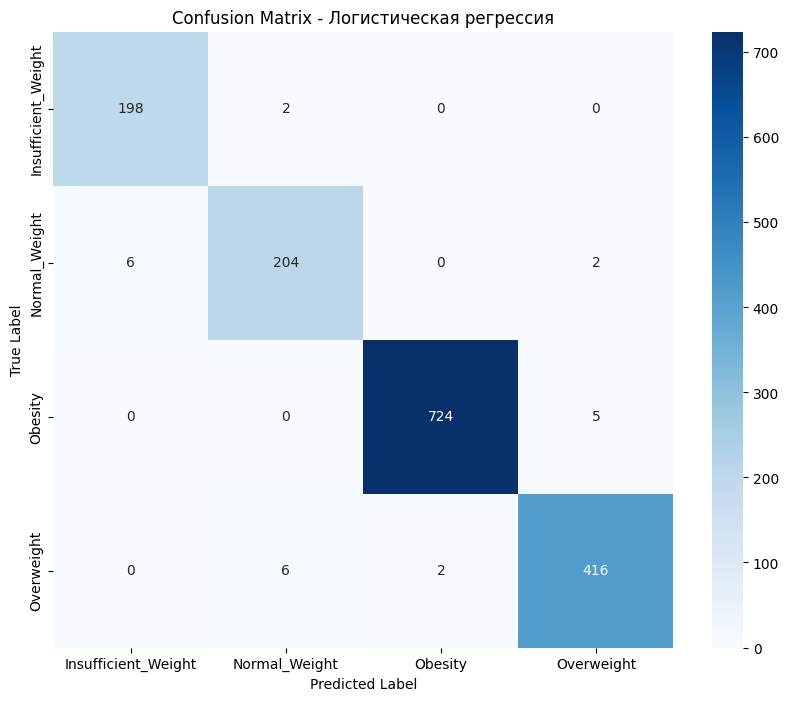

In [91]:
make_model(logreg_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["log_reg"], result_hw, tune_logistic_regression)

## C BMI

[I 2025-12-26 16:17:17,600] A new study created in memory with name: no-name-c478a709-d036-4ef1-b31e-32e287df1a92


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:17:17,818] Trial 0 finished with value: 0.8971355362816092 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.8971355362816092.
[I 2025-12-26 16:17:17,824] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.8971355362816092.
[I 2025-12-26 16:17:21,975] Trial 2 finished with value: 0.9777128704680086 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.9777128704680086.
[I 2025-12-26 16:17:21,984] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is tri

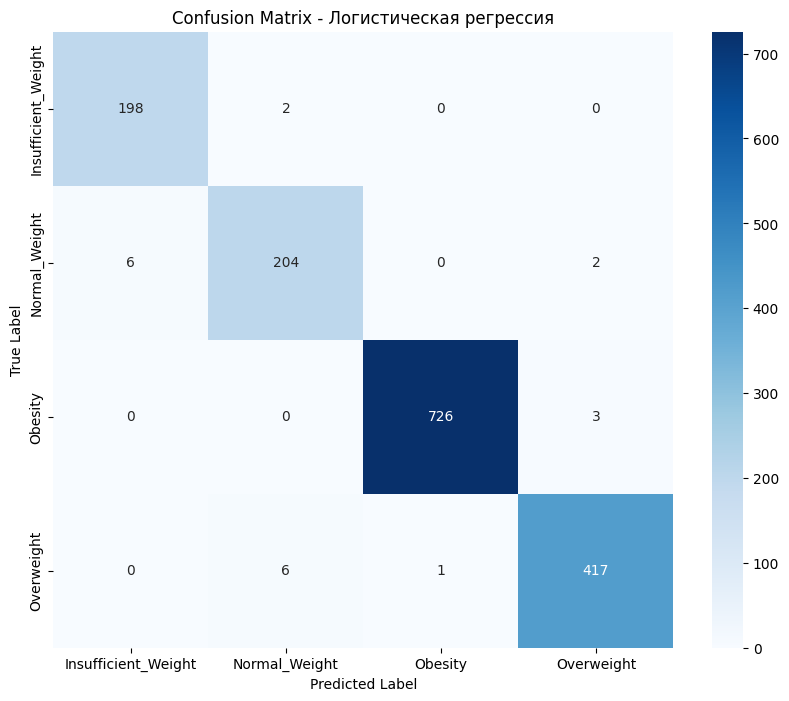

In [92]:
make_model(logreg_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["log_reg"], result_bmi, tune_logistic_regression)

## Без BMI и без Роста и Веса

[I 2025-12-26 16:20:58,309] A new study created in memory with name: no-name-fe6bc623-6219-467b-9a19-d8190872edd1


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:20:58,431] Trial 0 finished with value: 0.5681755373768703 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.5681755373768703.
[I 2025-12-26 16:20:58,435] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.5681755373768703.
[I 2025-12-26 16:20:58,904] Trial 2 finished with value: 0.5687460751094483 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.5687460751094483.
[I 2025-12-26 16:20:58,915] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is tri

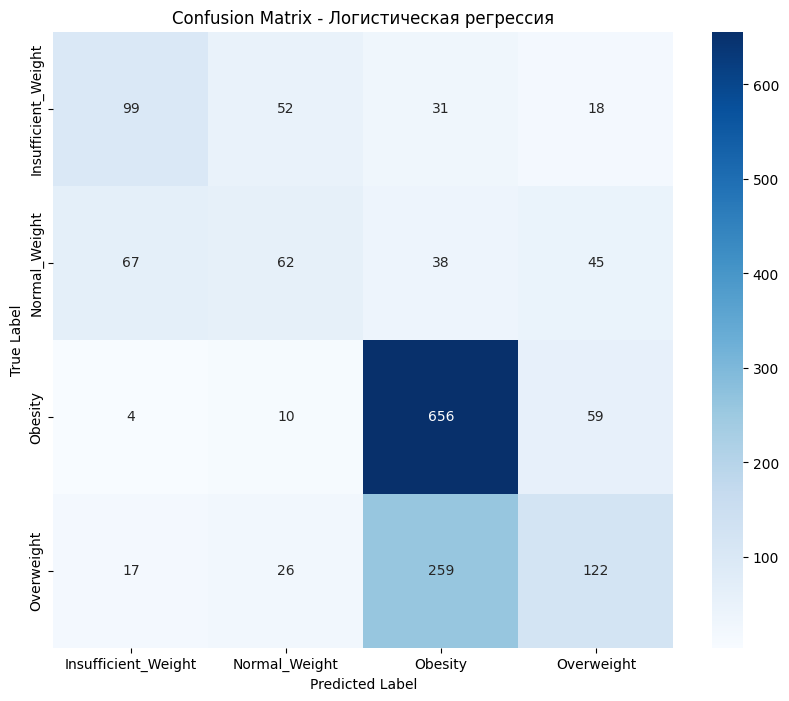

In [93]:
make_model(logreg_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["log_reg"], result_no_anthro, tune_logistic_regression)

# **2.3. SVM**

In [94]:
svm_pipeline = make_pipeline(
        StandardScaler(),
        SVC(random_state=42)
    )

## Без BMI

[I 2025-12-26 16:21:25,631] A new study created in memory with name: no-name-9ee24bb1-3f69-4475-ae38-2f9d38b3371b


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:21:26,179] Trial 0 finished with value: 0.9715132417970835 and parameters: {'C': 1.3292918943162166, 'kernel': 'linear', 'class_weight': None}. Best is trial 0 with value: 0.9715132417970835.
[I 2025-12-26 16:21:26,668] Trial 1 finished with value: 0.9492156511405742 and parameters: {'C': 0.14936568554617632, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9715132417970835.
[I 2025-12-26 16:21:28,187] Trial 2 finished with value: 0.9802763431398135 and parameters: {'C': 31.428808908401084, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.9802763431398135.
[I 2025-12-26 16:21:29,443] Trial 3 finished with value: 0.7001571379821856 and parameters: {'C': 1.976218934028007, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma_type': 'float', 'gamma_float': 0.0006290644294586153}. Best is trial 2 with value: 0.9802763431398135.
[I 2025-12-26 16:21:30,160] Trial 4 finished with value: 0.7485062336376093 and paramete

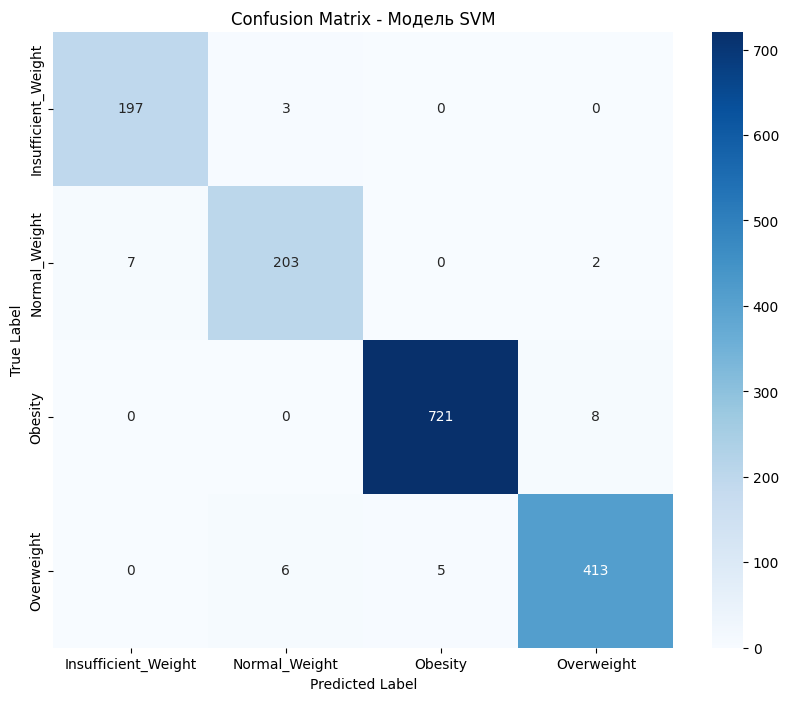

In [95]:
make_model(svm_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["svm"], result_hw, tune_svm)

## С BMI

[I 2025-12-26 16:22:30,960] A new study created in memory with name: no-name-868d70fb-52b8-4184-b4fb-3ff5830d481c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:22:31,846] Trial 0 finished with value: 0.9728529177692261 and parameters: {'C': 1.3292918943162166, 'kernel': 'linear', 'class_weight': None}. Best is trial 0 with value: 0.9728529177692261.
[I 2025-12-26 16:22:32,577] Trial 1 finished with value: 0.9513279229437823 and parameters: {'C': 0.14936568554617632, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9728529177692261.
[I 2025-12-26 16:22:33,716] Trial 2 finished with value: 0.9809322091576341 and parameters: {'C': 31.428808908401084, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.9809322091576341.
[I 2025-12-26 16:22:35,076] Trial 3 finished with value: 0.7153019401559094 and parameters: {'C': 1.976218934028007, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma_type': 'float', 'gamma_float': 0.0006290644294586153}. Best is trial 2 with value: 0.9809322091576341.
[I 2025-12-26 16:22:35,859] Trial 4 finished with value: 0.7632688450522259 and paramete

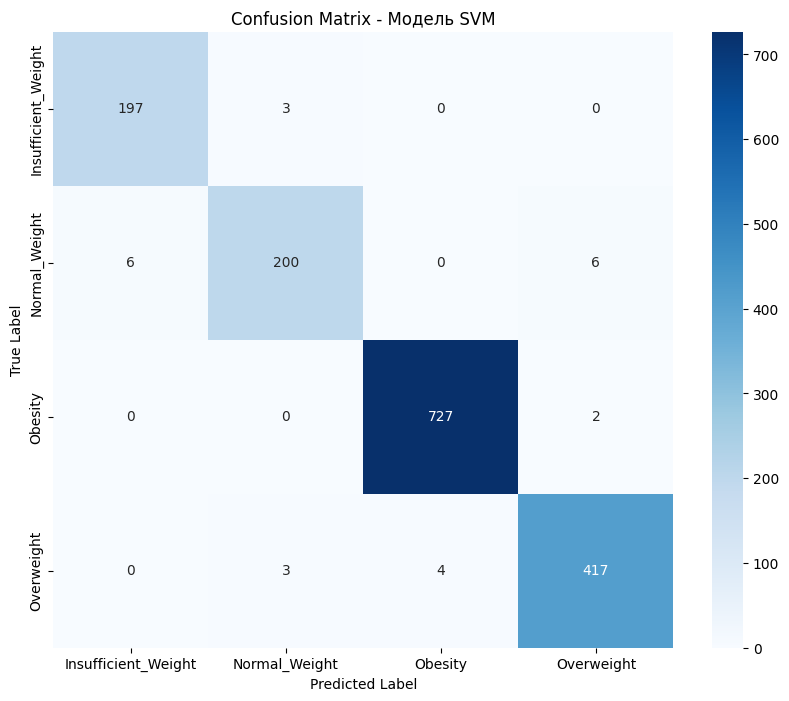

In [96]:
make_model(svm_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["svm"], result_bmi, tune_svm)

## Без BMI и без Роста и Веса

[I 2025-12-26 16:23:27,227] A new study created in memory with name: no-name-16aafe0e-059e-4dc7-ac79-2847174c94bb


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:23:28,974] Trial 0 finished with value: 0.5823922717280242 and parameters: {'C': 1.3292918943162166, 'kernel': 'linear', 'class_weight': None}. Best is trial 0 with value: 0.5823922717280242.
[I 2025-12-26 16:23:29,905] Trial 1 finished with value: 0.5795560078550656 and parameters: {'C': 0.14936568554617632, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5823922717280242.
[I 2025-12-26 16:23:38,866] Trial 2 finished with value: 0.5846037509811121 and parameters: {'C': 31.428808908401084, 'kernel': 'linear', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5846037509811121.
[I 2025-12-26 16:23:41,160] Trial 3 finished with value: 0.5579585059852397 and parameters: {'C': 1.976218934028007, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma_type': 'float', 'gamma_float': 0.0006290644294586153}. Best is trial 2 with value: 0.5846037509811121.
[I 2025-12-26 16:23:42,710] Trial 4 finished with value: 0.6862209953979082 and paramete

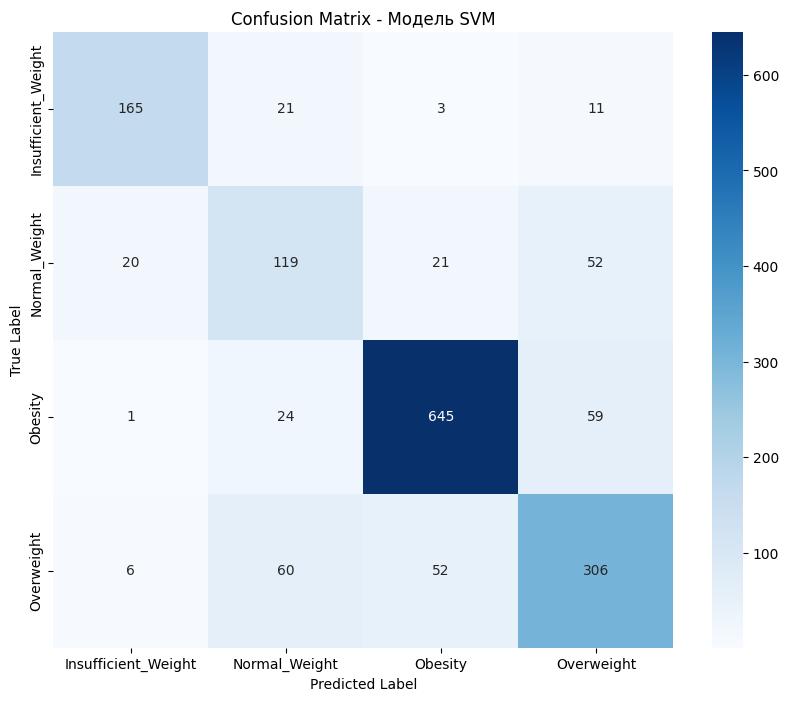

In [97]:
make_model(svm_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["svm"], result_no_anthro, tune_svm)

# **2.4. Дерево решений**

In [98]:
dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)


## Без BMI

[I 2025-12-26 16:24:55,726] A new study created in memory with name: no-name-fbc2c497-0a25-4abb-a745-3295e067908a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:24:55,923] Trial 0 finished with value: 0.9425317236972283 and parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 0 with value: 0.9425317236972283.
[I 2025-12-26 16:24:56,017] Trial 1 finished with value: 0.9317500336454073 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 0 with value: 0.9425317236972283.
[I 2025-12-26 16:24:56,101] Trial 2 finished with value: 0.8808993182385771 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9425317236972283.
[I 2025-12-26 16:24:56,195] Trial 3 finished with value: 0.8908881453658252 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0

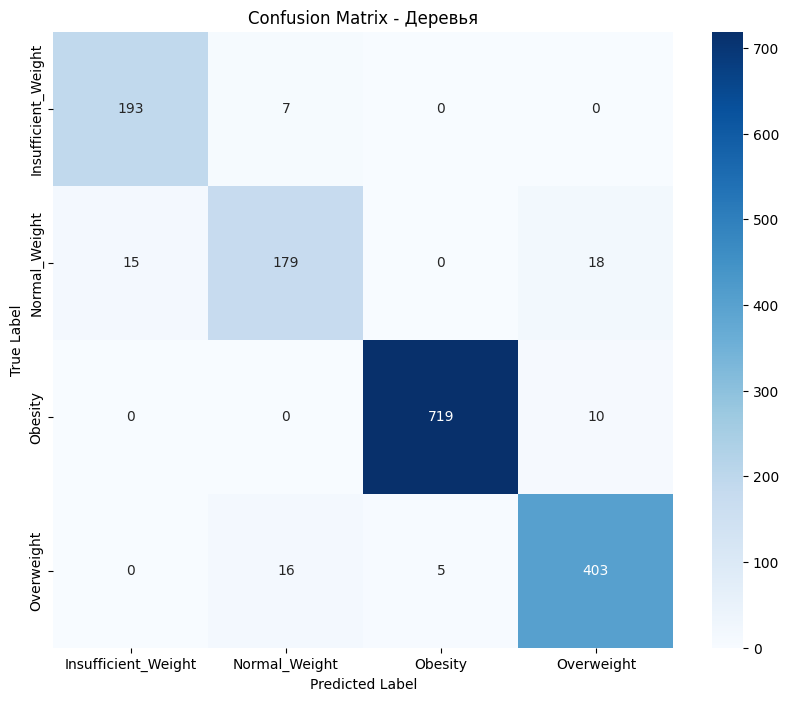

In [99]:
make_model(dt_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["tree"], result_hw, tune_decision_tree)

## C BMI

[I 2025-12-26 16:25:01,504] A new study created in memory with name: no-name-a2c13c9a-e271-4397-b0e9-d9104a78c377


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:25:01,616] Trial 0 finished with value: 0.9845948548690355 and parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 0 with value: 0.9845948548690355.
[I 2025-12-26 16:25:01,698] Trial 1 finished with value: 0.9891620263862472 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 1 with value: 0.9891620263862472.
[I 2025-12-26 16:25:01,801] Trial 2 finished with value: 0.9891620263862472 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9891620263862472.
[I 2025-12-26 16:25:01,900] Trial 3 finished with value: 0.9891620263862472 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 1 with value: 0

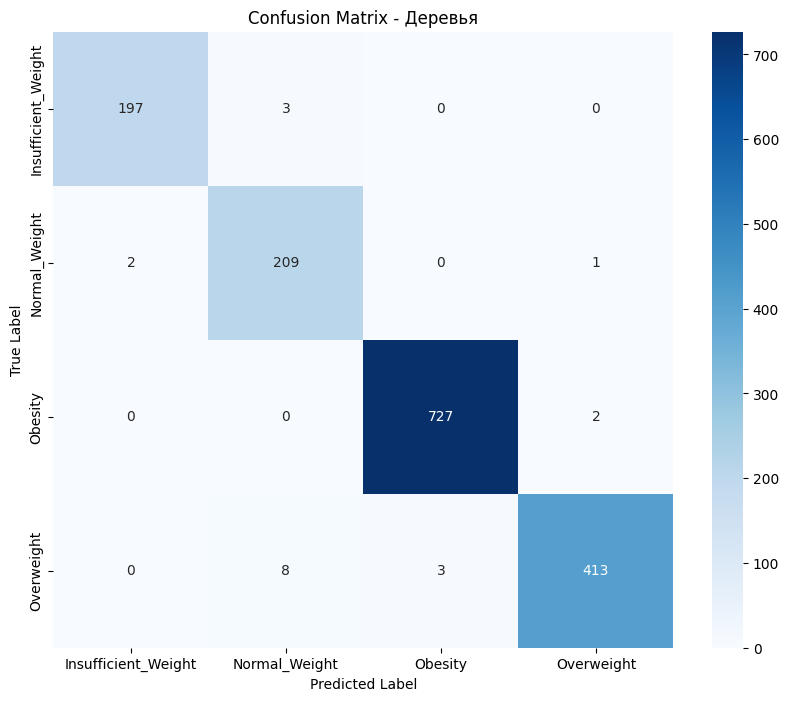

In [100]:
make_model(dt_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["tree"], result_bmi, tune_decision_tree)

## Без BMI и без Роста и Веса

[I 2025-12-26 16:25:08,011] A new study created in memory with name: no-name-43f78055-bf15-4610-b79f-ca734ca7d0b0


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:25:08,224] Trial 0 finished with value: 0.7258902028981226 and parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 0 with value: 0.7258902028981226.
[I 2025-12-26 16:25:08,351] Trial 1 finished with value: 0.696203466918405 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': None}. Best is trial 0 with value: 0.7258902028981226.
[I 2025-12-26 16:25:08,478] Trial 2 finished with value: 0.5882048407978484 and parameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7258902028981226.
[I 2025-12-26 16:25:08,601] Trial 3 finished with value: 0.5703220353984432 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.

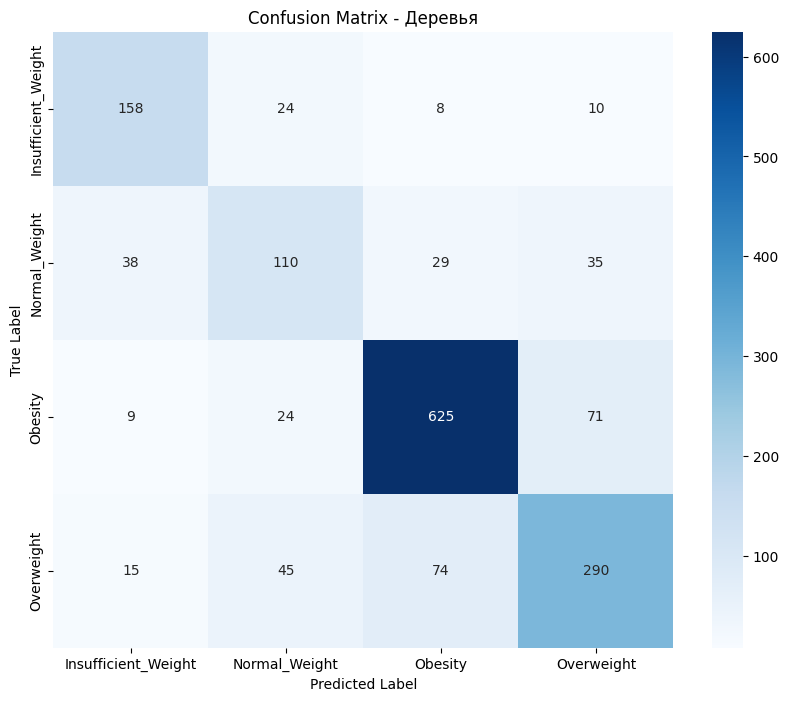

In [101]:
make_model(dt_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["tree"], result_no_anthro, tune_decision_tree)

# **2.5. Бэггинг (Random Forest)**

In [102]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(random_state=42)
)

## Без BMI

[I 2025-12-26 16:25:13,634] A new study created in memory with name: no-name-8dec9217-47b7-4ab2-8703-3f2d572ac717


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:25:15,641] Trial 0 finished with value: 0.9530413756031303 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.9530413756031303.
[I 2025-12-26 16:25:20,594] Trial 1 finished with value: 0.9288260668443482 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.9530413756031303.
[I 2025-12-26 16:25:23,305] Trial 2 finished with value: 0.9634587411431506 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 2 with value: 0.9634587411431506.
[I 2025-12-26 16:25:29,486] Trial 3 finished with value: 0.9533691229559965 and parameters: {'n_estimators': 500, 'cri

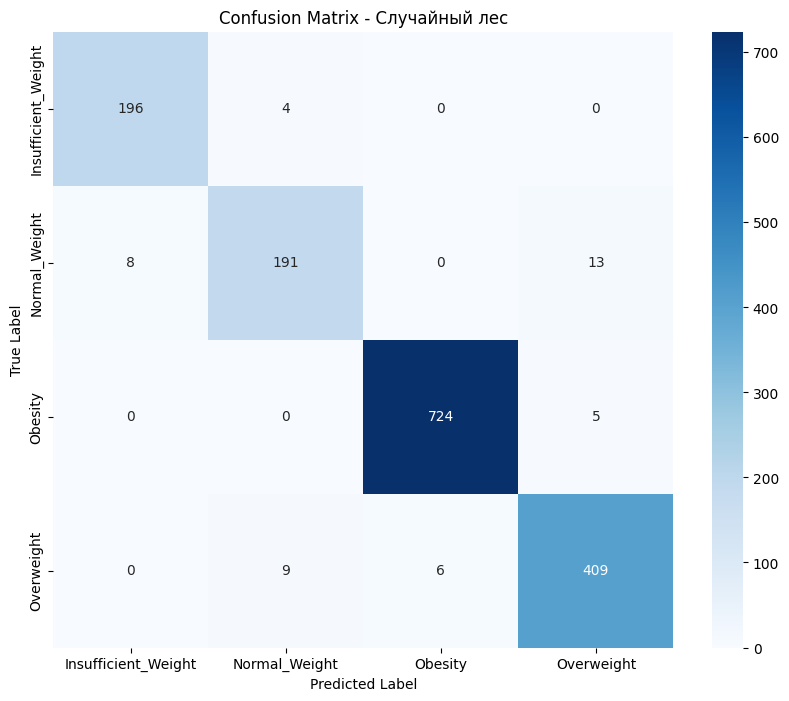

In [103]:
make_model(rf_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["rf"], result_hw, tune_random_forest)

## С BMI

[I 2025-12-26 16:28:14,766] A new study created in memory with name: no-name-df68d286-e6c5-487e-82b8-e8b3ba1396c5


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:28:16,495] Trial 0 finished with value: 0.989795085883693 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.
[I 2025-12-26 16:28:22,191] Trial 1 finished with value: 0.9872140038201005 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.
[I 2025-12-26 16:28:23,639] Trial 2 finished with value: 0.9885153734337818 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.
[I 2025-12-26 16:28:28,256] Trial 3 finished with value: 0.9891620263862472 and parameters: {'n_estimators': 500, 'criteri

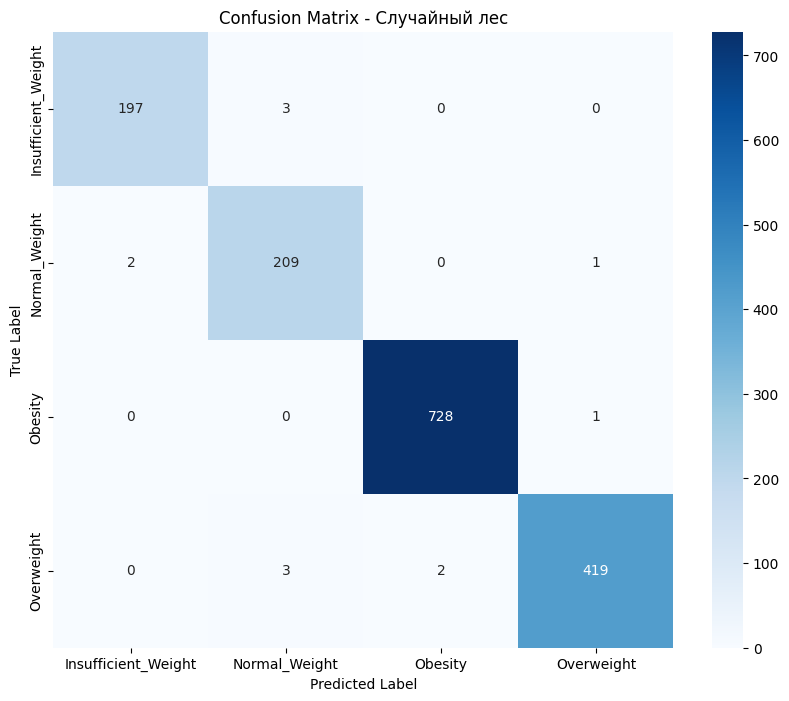

In [104]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi, tune_random_forest)

## Без BMI и без Роста и Веса

[I 2025-12-26 16:30:38,510] A new study created in memory with name: no-name-5604f1a4-f5a0-419f-81b7-c76053aacfe0


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-26 16:30:40,374] Trial 0 finished with value: 0.8096952594568861 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.
[I 2025-12-26 16:30:44,371] Trial 1 finished with value: 0.7127871367200824 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.
[I 2025-12-26 16:30:46,447] Trial 2 finished with value: 0.7898133282123873 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.
[I 2025-12-26 16:30:53,881] Trial 3 finished with value: 0.7747021052052913 and parameters: {'n_estimators': 500, 'cri

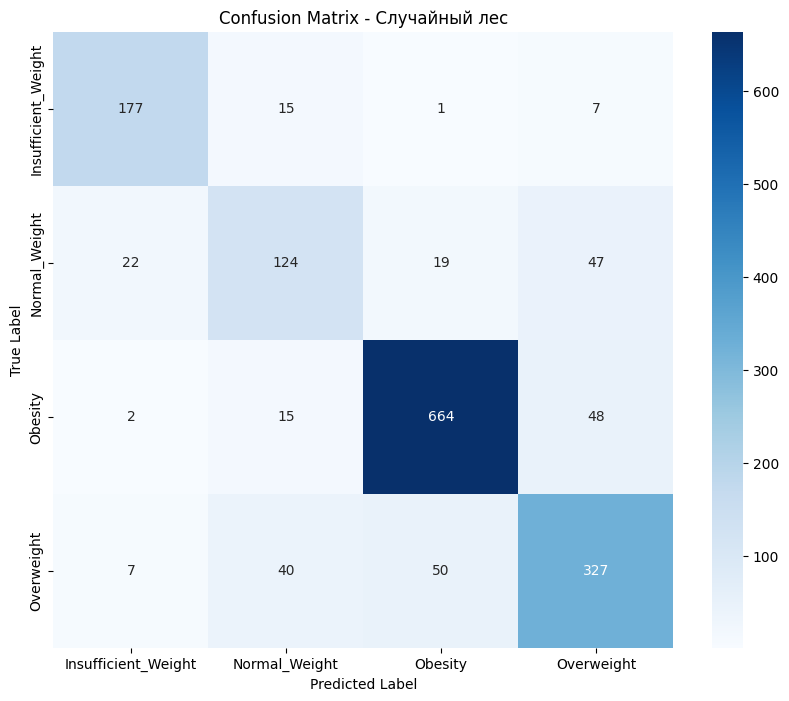

In [105]:
make_model(rf_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["rf"], result_no_anthro, tune_random_forest)

# **2.6. Стекинг**

In [106]:
estimators = [
    ('logreg', logreg_pipeline),
    ('svm', svm_pipeline),
    ('rf', rf_pipeline),
    ('dt', dt_pipeline)
]

final_estimator = LogisticRegression()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

stacking

StackingClassifier(cv=5,
                   estimators=[('logreg',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression(random_state=42))])),
                               ('svm',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(random_state=42))])),
                               ('rf',
                                Pipeline(steps=[('randomforestclassifier',
                                                 RandomForestClassifier(random_state=42))])),
                               ('dt',
                                Pipeline(steps=[('decisiontreeclassifier',
                                                 DecisionTreeClassifier(random_state=42))]))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

## Без BMI

[I 2025-12-26 16:33:00,345] A new study created in memory with name: no-name-739f4e19-374f-43d9-a83d-f7f19b1b5c7d


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-26 16:33:06,335] Trial 0 finished with value: 0.9597981166965486 and parameters: {'C': 1.3292918943162166, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1312}. Best is trial 0 with value: 0.9597981166965486.
[I 2025-12-26 16:33:11,888] Trial 1 finished with value: 0.9534350980121339 and parameters: {'C': 0.14936568554617632, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 2940}. Best is trial 0 with value: 0.9597981166965486.
[I 2025-12-26 16:33:17,026] Trial 2 finished with value: 0.962013633504574 and parameters: {'C': 31.428808908401084, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced', 'max_iter': 2050}. Best is trial 2 with value: 0.962013633504574.
[I 2025-12-26 16:33:24,018] Trial 3 finished with value: 0.9582948170665281 and parameters: {'C': 1.976218934028007, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1733}. Best is trial 2 with value: 0.962013633504574.
[I 2025-12-26 16:33:

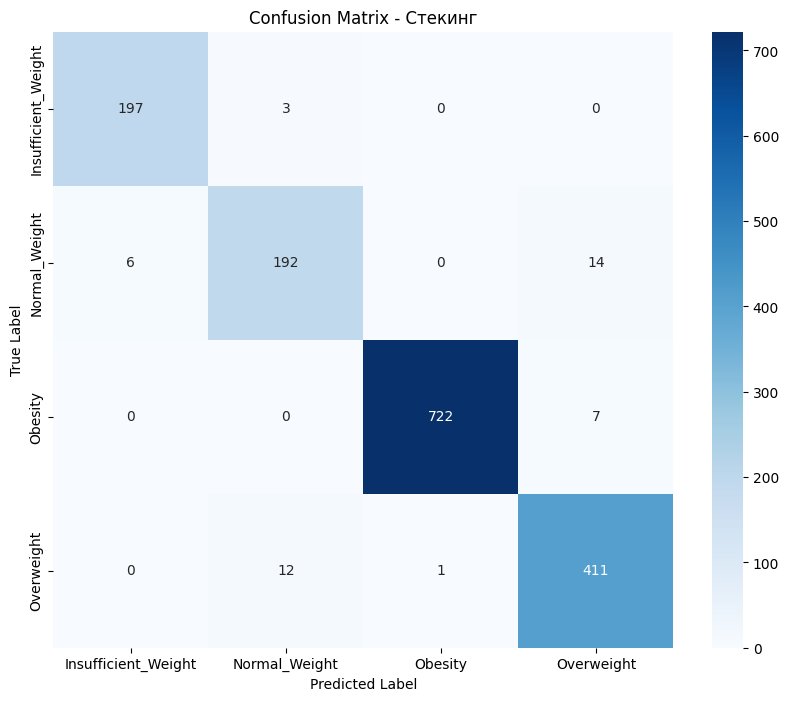

In [107]:
make_model(stacking, X_HW_train, Y_HW_train, MODEL_NAMES["stacking"], result_hw, tune_stacking)

## C BMI

[I 2025-12-26 16:36:35,456] A new study created in memory with name: no-name-68fc1a16-fff2-4a18-b262-bedc88dd6d01


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-26 16:36:41,603] Trial 0 finished with value: 0.9879135989778242 and parameters: {'C': 1.3292918943162166, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1312}. Best is trial 0 with value: 0.9879135989778242.
[I 2025-12-26 16:36:46,387] Trial 1 finished with value: 0.9815521587448616 and parameters: {'C': 0.14936568554617632, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 2940}. Best is trial 0 with value: 0.9879135989778242.
[I 2025-12-26 16:36:52,705] Trial 2 finished with value: 0.9866655399924431 and parameters: {'C': 31.428808908401084, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced', 'max_iter': 2050}. Best is trial 0 with value: 0.9879135989778242.
[I 2025-12-26 16:36:57,427] Trial 3 finished with value: 0.9847896236685981 and parameters: {'C': 1.976218934028007, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1733}. Best is trial 0 with value: 0.9879135989778242.
[I 2025-12-26 16:

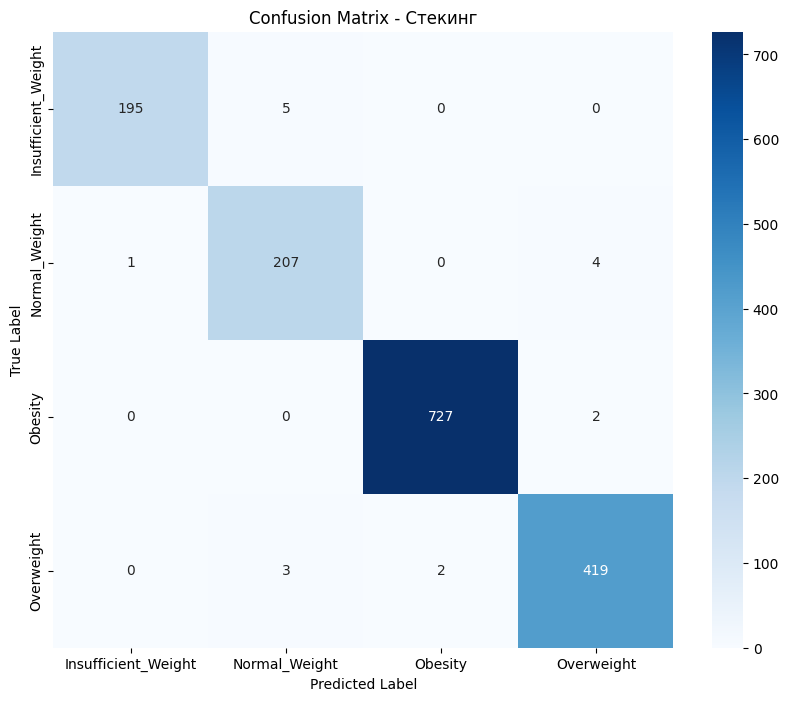

In [108]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi, tune_stacking)

## Без BMI и без Роста и Веса

[I 2025-12-26 16:39:34,232] A new study created in memory with name: no-name-78e9148f-92ea-4e91-8b23-bf2008366113


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-26 16:39:40,908] Trial 0 finished with value: 0.7842051526350867 and parameters: {'C': 1.3292918943162166, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1312}. Best is trial 0 with value: 0.7842051526350867.
[I 2025-12-26 16:39:46,286] Trial 1 finished with value: 0.7726353534928873 and parameters: {'C': 0.14936568554617632, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 2940}. Best is trial 0 with value: 0.7842051526350867.
[I 2025-12-26 16:39:51,498] Trial 2 finished with value: 0.8027937060878992 and parameters: {'C': 31.428808908401084, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced', 'max_iter': 2050}. Best is trial 2 with value: 0.8027937060878992.
[I 2025-12-26 16:39:58,419] Trial 3 finished with value: 0.7986768493837136 and parameters: {'C': 1.976218934028007, 'penalty': 'l2', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1733}. Best is trial 2 with value: 0.8027937060878992.
[I 2025-12-26 16:

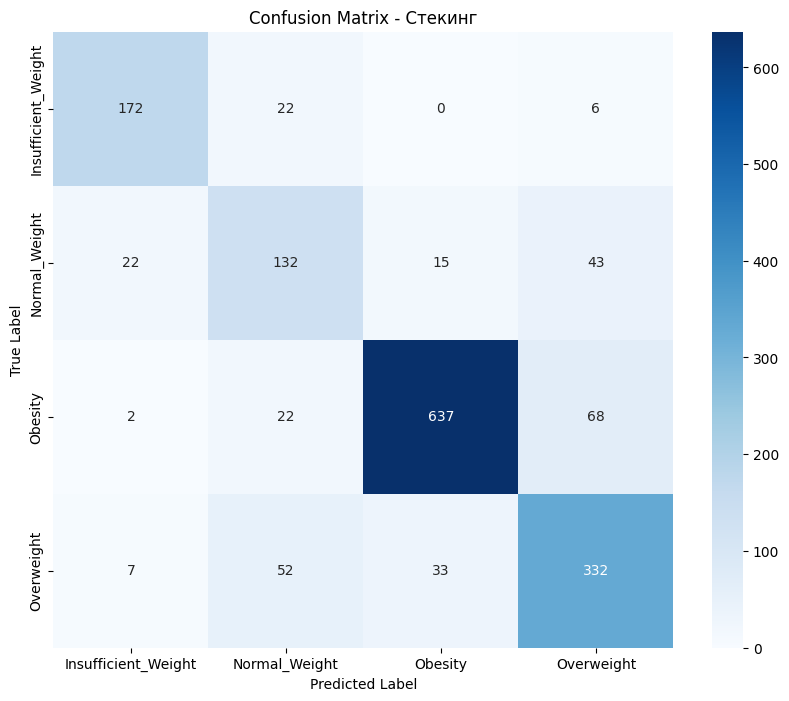

In [109]:
make_model(stacking, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["stacking"], result_no_anthro, tune_stacking)

# **2.7. Бустинг (CatBoost)**

In [110]:
cbreg = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

In [111]:
make_catboost_model(cbreg, X_HW_cat_train, Y_HW_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_hw, tune_catboost)

[I 2025-12-26 16:42:49,493] A new study created in memory with name: no-name-a442b149-2385-4d06-b2ce-d495d7be31b8


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-12-26 16:42:53,723] Trial 0 finished with value: 0.0 and parameters: {'balance': 'Balanced', 'learning_rate': 0.1205712628744377, 'depth': 8, 'l2_leaf_reg': 2.5361081166471375e-07, 'border_count': 66}. Best is trial 0 with value: 0.0.
[I 2025-12-26 16:43:00,063] Trial 1 finished with value: 0.0 and parameters: {'balance': 'Balanced', 'learning_rate': 0.07725378389307355, 'depth': 8, 'l2_leaf_reg': 1.5320059381854043e-08, 'border_count': 249}. Best is trial 0 with value: 0.0.
[I 2025-12-26 16:43:00,080] Trial 2 finished with value: -1.0 and parameters: {'balance': None, 'learning_rate': 0.01855998084649059, 'depth': 5, 'l2_leaf_reg': 5.472429642032198e-06, 'border_count': 149}. Best is trial 0 with value: 0.0.
[I 2025-12-26 16:43:00,100] Trial 3 finished with value: -1.0 and parameters: {'balance': None, 'learning_rate': 0.08012737503998542, 'depth': 4, 'l2_leaf_reg': 4.258943089524393e-06, 'border_count': 114}. Best is trial 0 with value: 0.0.
[I 2025-12-26 16:43:03,016] Trial 

In [112]:
make_catboost_model(cbreg, X_BMI_cat_train, Y_BMI_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_bmi)


CatBoost CV results [CatBoost]
Accuracy (Micro F1): 0.9891
Total F1 (Macro/Micro): 0.9892
LogLoss: 0.1457
CV time: 4.24 sec


## Без BMI и без Роста и Веса

In [113]:
make_catboost_model(cbreg, X_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_no_anthro)


CatBoost CV results [CatBoost]
Accuracy (Micro F1): 0.6434
Total F1 (Macro/Micro): 0.6050
LogLoss: 0.8756
CV time: 5.83 sec


# **3.1. Таблицы сравнений**

Итак, выведем полученные значения из наших моделей:

In [114]:
print("\n### 1.  Результаты без показателя BMI (Рост/Вес включены)")
display_formatted_table(result_hw)
print("\n### 2.  Результаты c показателем BMI (Рост/Вес не включены)")
display_formatted_table(result_bmi)
print("\n### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)")
display_formatted_table(result_no_anthro)


### 1.  Результаты без показателя BMI (Рост/Вес включены)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Логистическая регрессия,0.9853,0.9853,0.0487,0.9853,0.9854,0.9995,0.68
Модель SVM,0.9802,0.9802,0.0629,0.9802,0.9803,0.9996,5.76
Стекинг,0.9725,0.9725,0.0805,0.9725,0.9726,0.9983,34.58
Случайный лес,0.9711,0.9712,0.0803,0.9712,0.9711,0.9986,18.12
Деревья,0.9544,0.9546,1.0265,0.9546,0.9545,0.9806,0.24
CatBoost,0.9469,0.9469,0.1702,NaN,NaN,NaN,6.00



### 2.  Результаты c показателем BMI (Рост/Вес не включены)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Случайный лес,0.9923,0.9923,0.1262,0.9923,0.9924,0.9998,13.75
CatBoost,0.9892,0.9891,0.1457,NaN,NaN,NaN,4.24
Стекинг,0.9892,0.9891,0.0332,0.9891,0.9892,0.9998,13.68
Деревья,0.9879,0.9879,0.2680,0.9879,0.9881,0.9952,0.31
Логистическая регрессия,0.9872,0.9872,0.0466,0.9872,0.9873,0.9997,23.83
Модель SVM,0.9846,0.9847,0.0663,0.9847,0.9846,0.9994,4.45



### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)


,F1-Score,Accuracy,LogLoss,Recall),Precision,ROC_AUC,Время CV (сек)
Случайный лес,0.8242,0.8256,0.5119,0.8256,0.8232,0.9541,10.64
Стекинг,0.8161,0.8134,0.5163,0.8134,0.8202,0.9499,16.74
Модель SVM,0.7906,0.7891,0.5646,0.7891,0.7922,0.9317,6.24
Деревья,0.7547,0.7559,6.3364,0.7559,0.7543,0.8628,0.21
CatBoost,0.6050,0.6434,0.8756,NaN,NaN,NaN,5.83
Логистическая регрессия,0.5675,0.6000,0.9036,0.6000,0.5697,0.8075,1.90


# **3.2 Тестирование лучших моделей на тестовых данных**

### 1.  Результаты без показателя BMI (Рост/Вес включены). Лучшая модель - Логистическая регрессия.

In [25]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

[I 2025-12-27 14:55:46,427] A new study created in memory with name: no-name-478f47cf-9b56-49bf-9eb5-11a66d06a8fa
Best trial: 0. Best value: 0.887133:   2%|▏         | 1/50 [00:05<04:30,  5.51s/it]

[I 2025-12-27 14:55:51,936] Trial 0 finished with value: 0.8871326279942858 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 3832}. Best is trial 0 with value: 0.8871326279942858.
[I 2025-12-27 14:55:51,948] Trial 1 finished with value: -inf and parameters: {'C': 0.0013289448722869186, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 2165}. Best is trial 0 with value: 0.8871326279942858.


Best trial: 2. Best value: 0.97196:   8%|▊         | 4/50 [00:10<02:32,  3.32s/it] 

[I 2025-12-27 14:55:57,056] Trial 2 finished with value: 0.9719603618034117 and parameters: {'C': 4.689400963537685, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1185, 'l1_ratio': 0.6075448519014384}. Best is trial 2 with value: 0.9719603618034117.
[I 2025-12-27 14:55:57,067] Trial 3 finished with value: -inf and parameters: {'C': 0.010547383621352036, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'class_weight': None, 'max_iter': 1488, 'l1_ratio': 0.4951769101112702}. Best is trial 2 with value: 0.9719603618034117.
[I 2025-12-27 14:55:57,078] Trial 4 finished with value: -inf and parameters: {'C': 0.001608166928363465, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 4101}. Best is trial 2 with value: 0.9719603618034117.


Best trial: 5. Best value: 0.982835:  12%|█▏        | 6/50 [00:17<01:59,  2.71s/it]

...

[I 2025-12-27 14:57:44,707] Trial 46 finished with value: 0.9821953799807029 and parameters: {'C': 518.4596860761797, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1943, 'l1_ratio': 0.1410496157875809}. Best is trial 5 with value: 0.9828345681988525.


Best trial: 5. Best value: 0.982835:  96%|█████████▌| 48/50 [02:01<00:06,  3.08s/it]

[I 2025-12-27 14:57:48,018] Trial 47 finished with value: 0.9821982736148053 and parameters: {'C': 75.78863957666991, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 2223}. Best is trial 5 with value: 0.9828345681988525.


Best trial: 5. Best value: 0.982835: 100%|██████████| 50/50 [02:03<00:00,  2.47s/it]


[I 2025-12-27 14:57:49,849] Trial 48 finished with value: 0.9776110604798894 and parameters: {'C': 42.65837878236933, 'penalty': 'l2', 'solver': 'saga', 'class_weight': None, 'max_iter': 2511}. Best is trial 5 with value: 0.9828345681988525.
[I 2025-12-27 14:57:49,881] Trial 49 finished with value: -inf and parameters: {'C': 3.19172205755257, 'penalty': 'elasticnet', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 3251, 'l1_ratio': 0.5417508520960093}. Best is trial 5 with value: 0.9828345681988525.

Лучшие параметры:
  C: 433.5045392775131
  penalty: elasticnet
  solver: saga
  class_weight: balanced
  max_iter: 2085
  l1_ratio: 0.8287375091519293
Classification Report - Test Data:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.99      0.99       200
      Normal_Weight       0.99      0.98      0.98       212
            Obesity       1.00      1.00      1.00       729
         Overweight       1.00      1.00      1.

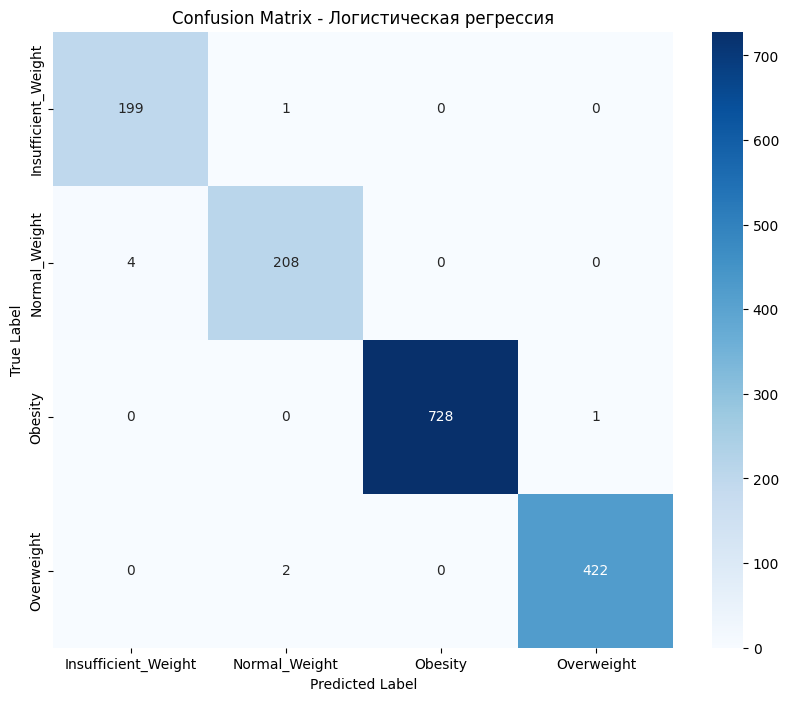

In [26]:
make_model(logreg_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["log_reg"], result_hw, tune_logistic_regression, X_test=X_HW_test, y_test=Y_HW_test)

### 2.  Результаты без роста и веса (BMI включен).  Лучшая модель - Случайный лес.

In [28]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(random_state=42)
)

[I 2025-12-27 15:12:53,755] A new study created in memory with name: no-name-23bd2753-1040-4fca-898b-48e39e10ef21
Best trial: 0. Best value: 0.989795:   2%|▏         | 1/50 [00:06<05:18,  6.49s/it]

[I 2025-12-27 15:13:00,248] Trial 0 finished with value: 0.989795085883693 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.


Best trial: 0. Best value: 0.989795:   4%|▍         | 2/50 [00:12<05:00,  6.27s/it]

[I 2025-12-27 15:13:06,358] Trial 1 finished with value: 0.9872140038201005 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.989795085883693.


Best trial: 0. Best value: 0.989795:   6%|▌         | 3/50 [00:17<04:22,  5.58s/it]

...

[I 2025-12-27 15:14:08,695] Trial 47 finished with value: 0.9891742900191264 and parameters: {'n_estimators': 500, 'criterion': 'entropy', 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 44 with value: 0.992975079524724.


Best trial: 44. Best value: 0.992975:  98%|█████████▊| 49/50 [01:16<00:01,  1.90s/it]

[I 2025-12-27 15:14:10,425] Trial 48 finished with value: 0.9873033523644906 and parameters: {'n_estimators': 400, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 44 with value: 0.992975079524724.


Best trial: 44. Best value: 0.992975: 100%|██████████| 50/50 [01:18<00:00,  1.57s/it]


[I 2025-12-27 15:14:12,455] Trial 49 finished with value: 0.9898471336828082 and parameters: {'n_estimators': 450, 'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 44 with value: 0.992975079524724.

Лучшие параметры:
  n_estimators: 450
  criterion: gini
  max_depth: 13
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  class_weight: balanced
Classification Report - Test Data:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       200
      Normal_Weight       1.00      1.00      1.00       212
            Obesity       1.00      1.00      1.00       729
         Overweight       1.00      1.00      1.00       424

           accuracy                           1.00      1565
          macro avg       1.00      1.00      1.00      1565
       weighted avg       1.00      1.00      1.00      1565


LogLoss 

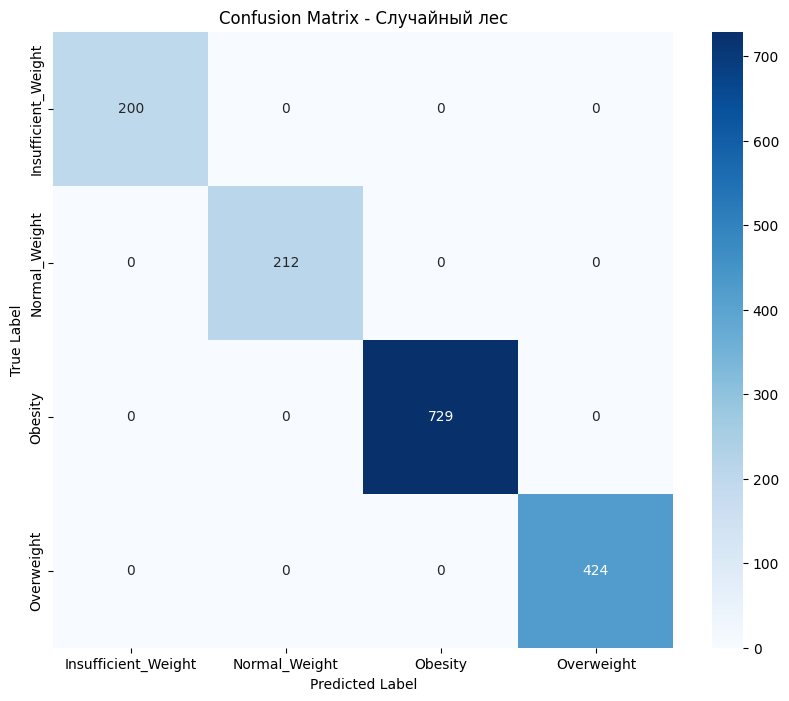

In [29]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi, tune_random_forest, X_test=X_BMI_test, y_test=Y_BMI_test)

### 3.  Результаты без роста, веса и BMI.  Лучшая модель - Случайный лес.

[I 2025-12-27 15:16:38,295] A new study created in memory with name: no-name-67491d39-5a67-4378-b8c4-7dbbec9e91bd
Best trial: 0. Best value: 0.809695:   2%|▏         | 1/50 [00:01<00:52,  1.08s/it]

[I 2025-12-27 15:16:39,372] Trial 0 finished with value: 0.8096952594568861 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.


Best trial: 0. Best value: 0.809695:   4%|▍         | 2/50 [00:03<01:27,  1.83s/it]

[I 2025-12-27 15:16:41,729] Trial 1 finished with value: 0.7127871367200824 and parameters: {'n_estimators': 500, 'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.8096952594568861.


Best trial: 0. Best value: 0.809695:   6%|▌         | 3/50 [00:04<01:02,  1.33s/it]

...

[I 2025-12-27 15:17:34,533] Trial 47 finished with value: 0.8122875314601791 and parameters: {'n_estimators': 250, 'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 32 with value: 0.8172787984018036.


Best trial: 32. Best value: 0.817279:  98%|█████████▊| 49/50 [00:58<00:01,  1.39s/it]

[I 2025-12-27 15:17:36,374] Trial 48 finished with value: 0.7985698343891676 and parameters: {'n_estimators': 400, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 32 with value: 0.8172787984018036.


Best trial: 32. Best value: 0.817279: 100%|██████████| 50/50 [00:58<00:00,  1.17s/it]


[I 2025-12-27 15:17:36,933] Trial 49 finished with value: 0.8063252710600736 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 32 with value: 0.8172787984018036.

Лучшие параметры:
  n_estimators: 300
  criterion: gini
  max_depth: 15
  min_samples_split: 3
  min_samples_leaf: 1
  max_features: sqrt
  class_weight: balanced
Classification Report - Test Data:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       200
      Normal_Weight       0.98      0.98      0.98       212
            Obesity       0.98      0.99      0.98       729
         Overweight       0.99      0.97      0.98       424

           accuracy                           0.98      1565
          macro avg       0.98      0.98      0.98      1565
       weighted avg       0.98      0.98      0.98      1565


LogLoss (

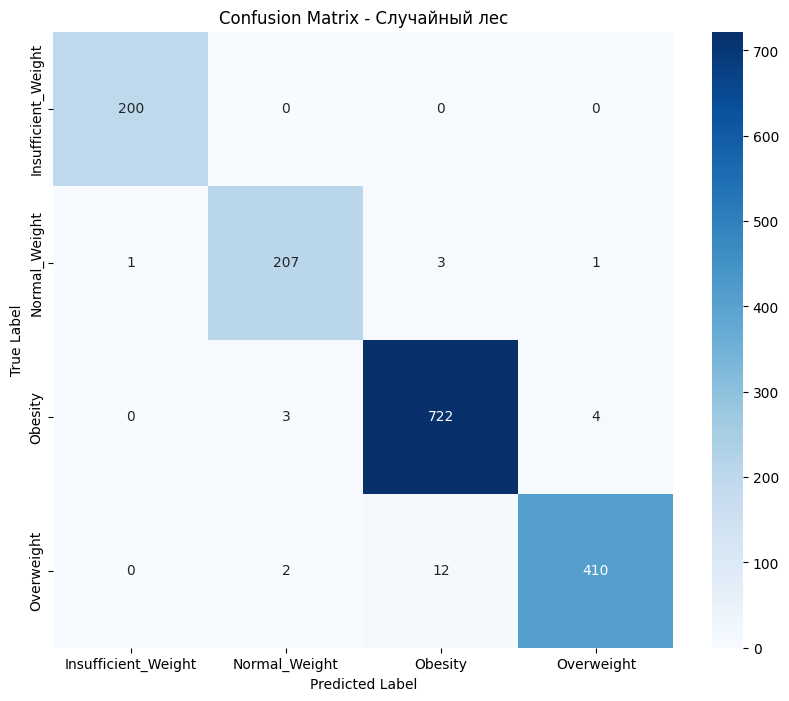

In [30]:
make_model(rf_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["rf"], result_no_anthro, tune_random_forest, X_test=X_NO_ANTHRO_test, y_test=Y_NO_ANTHRO_test)

# **3.3 Выводы**

##### Таким образом, в результате нашего проекта мы обучили 6 моделей машинного обучения на 3-х разных типах данных: 
1. С ростом и весом 
2. Без роста и веса, но с BMI(индексом массы тела)
3. Без роста, веса и BMI

Обучение на первых двух типах данных не совсем является машинным обучением, так как имея рост, вес или индекс массы тела мы можем однозначно сказать имеется ли у человека ожирение или нет, потому как это однозначно определяется этими параметрами. Самым интересным представляется для проекта 3 таблица с данными без этих параметров, так как мы можем предсказать имеется ли ожирение у человека только по вредным пищевым и поведенческим привычкам, а также по образу их жизни и наличию в их семье схожих заболеваний.

Результат обучения на тренировочных данных с помощью кросс-валидации можно увидеть в таблице в пункте 3.1, где в качестве главной метрики мы выбрали F1-weighted из-за специфики задачи. С помощью данной таблицы мы видим насколько хорошо обучились модели по выбранным метрикам, и провели проверку качества лучших моделей на определенных типах данных. Результат можно увидеть в пункте 3.2.

Таким образом, видим, что имея рост, вес или BMI мы имеем очень большой показатель точности у моделей близкий к 100%, что для медицинских учреждений, где будет использоваться данное ПО, является отличным результатам и позволит предотвращать в будущем риск ожирения у людей.

Исследуя данные без роста, веса и BMI мы добились также неплохих результатов, превышающих 82% точности на кросс-валидации, и 98% на тестовых данных, что делает данную модель также применимой в медицинских учреждениях.